# 05 – Interpretability of the MaskablePPO+CNN Pac-Man policy

We load the MaskablePPO agent trained in [`02_rl_training.ipynb`](02_rl_training.ipynb) on `PacmanGridEnv` and ask **why** it picks the action it picks for a given state.

Two complementary techniques are applied:
1. **Permutation channel importance** — how much the critic's value V(s) changes when each input channel (walls, pellets, Pac-Man position, …) is shuffled across the batch
2. **SHAP GradientExplainer** — gradient-based attribution over the 6 CNN input channels

Figures are saved to [`reports/`](../reports/) for the presentation.


In [19]:
import sys
from pathlib import Path
sys.path.insert(0, '..')

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.environment.pacman_env import PacmanGridEnv

REPORTS_DIR = Path('..') / 'reports'
REPORTS_DIR.mkdir(exist_ok=True)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cuda:0


## Load the MaskablePPO policy

We load the checkpoint saved by `02_rl_training.ipynb` at `models/ppo_pacman.zip`.
The environment is `PacmanGridEnv` — observation shape `(6, 31, 28)`.


In [20]:
from sb3_contrib import MaskablePPO

env = PacmanGridEnv()
ckpt = Path('..') / 'models' / 'ppo_pacman.zip'

model = MaskablePPO.load(str(ckpt), env=env, device=device)
print(f'Loaded {ckpt}')
print(f'obs_space : {env.observation_space}')
print(f'act_space : {env.action_space}')


Loaded ../models/ppo_pacman.zip
obs_space : Box(0.0, 1.0, (6, 31, 28), float32)
act_space : Discrete(4)


In [21]:
def get_values(obs_batch):
    """Return V(s) from the PPO critic for a batch of observations."""
    obs_t = torch.FloatTensor(obs_batch).to(model.device)
    with torch.no_grad():
        values = model.policy.predict_values(obs_t)
    return values.cpu().numpy().flatten()


def collect_states(n=200, seed=0):
    states = []
    obs, _ = env.reset(seed=seed)
    while len(states) < n:
        states.append(obs.astype(np.float32))
        masks  = env.action_masks()
        action, _ = model.predict(obs, action_masks=masks, deterministic=False)
        obs, _, terminated, truncated, _ = env.step(int(action))
        if terminated or truncated:
            obs, _ = env.reset()
    return np.stack(states)


states = collect_states(n=200, seed=0)
print('collected states:', states.shape)   # (200, 6, 31, 28)
print('value range:    ', get_values(states).min().round(3),
      '..', get_values(states).max().round(3))


collected states: (200, 6, 31, 28)
value range:     0.312 .. 7.875


## 1. Permutation channel importance

`PacmanGridEnv` gives the CNN a `(6, 31, 28)` tensor with six binary/scalar channels:

| Channel | Index | Meaning |
|---------|-------|---------|
| `walls` | 0 | static maze walls |
| `pellets` | 1 | remaining pellets |
| `power_pellets` | 2 | remaining power pellets |
| `pacman` | 3 | Pac-Man's current position |
| `ghosts_normal` | 4 | positions of non-frightened ghosts |
| `ghosts_frightened` | 5 | positions of frightened ghosts |

We measure how much the PPO critic's value V(s) changes when each channel is shuffled across the batch.


In [22]:
CHANNELS = {
    'walls':             0,
    'pellets':           1,
    'power_pellets':     2,
    'pacman':            3,
    'ghosts_normal':     4,
    'ghosts_frightened': 5,
}

rng = np.random.default_rng(0)

base_values = get_values(states)   # (N,)

importances = {}
for name, ch_idx in CHANNELS.items():
    perm = rng.permutation(len(states))
    shuffled = states.copy()
    shuffled[:, ch_idx, :, :] = states[perm, ch_idx, :, :]
    shuf_values = get_values(shuffled)
    importances[name] = float(np.mean(np.abs(base_values - shuf_values)))

for k, v in sorted(importances.items(), key=lambda x: -x[1]):
    print(f'{k:<20s}  ΔV = {v:.4f}')


pellets               ΔV = 1.5027
ghosts_frightened     ΔV = 0.7607
pacman                ΔV = 0.3439
power_pellets         ΔV = 0.2081
ghosts_normal         ΔV = 0.1557
walls                 ΔV = 0.0000


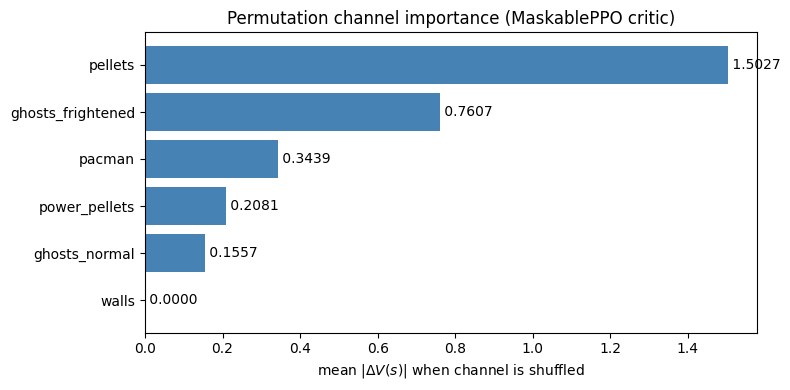

In [23]:
names  = list(importances.keys())
values = [importances[n] for n in names]
order  = np.argsort(values)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh([names[i] for i in order], [values[i] for i in order], color='steelblue')
ax.set_xlabel(r'mean $|\Delta V(s)|$ when channel is shuffled')
ax.set_title('Permutation channel importance (MaskablePPO critic)')
for i, v in enumerate([values[j] for j in order]):
    ax.text(v, i, f' {v:.4f}', va='center')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'interpretability_permutation.png', dpi=150)
plt.show()


## 2. SHAP channel attribution — GradientExplainer

We wrap the PPO critic (CNN feature extractor → MLP → value head) as a single `nn.Module` and run `shap.GradientExplainer` on it.  
SHAP values have shape `(N, 6, 31, 28)`. We then aggregate by summing `|SHAP|` per channel to get a single importance score per channel — directly comparable to the permutation results above.


In [28]:
import shap
import torch.nn as nn

CHANNEL_NAMES = list(CHANNELS.keys())

# Wrapper: CNN extractor + mlp_extractor value path + value head
# Must return (N, 1) — GradientExplainer requires 2D output for indexing
class PolicyValueWrapper(nn.Module):
    def __init__(self, policy):
        super().__init__()
        self.fe  = policy.features_extractor
        self.mlp = policy.mlp_extractor
        self.vn  = policy.value_net

    def forward(self, obs):
        features = self.fe(obs)
        _, latent_vf = self.mlp(features)
        return self.vn(latent_vf)  # (N, 1)


value_wrapper = PolicyValueWrapper(model.policy).eval().to(model.device)

background = torch.FloatTensor(states[:20]).to(model.device)
explain_t  = torch.FloatTensor(states[20:50]).to(model.device)

explainer = shap.GradientExplainer(value_wrapper, background)
shap_vals = explainer.shap_values(explain_t)

# GradientExplainer returns list of arrays, one per output.
# For output (N, 1): shap_vals is list of 1 array shaped (N, 6, 31, 28, 1)
if isinstance(shap_vals, list):
    shap_arr = np.abs(np.array(shap_vals[0]))
else:
    shap_arr = np.abs(np.array(shap_vals))

# Drop trailing output dim: (N, 6, 31, 28, 1) → (N, 6, 31, 28)
if shap_arr.ndim == 5:
    shap_arr = shap_arr[..., 0]

print(f'shap_arr shape: {shap_arr.shape}')  # expect (30, 6, 31, 28)

# Aggregate: mean |SHAP| per channel across samples and spatial dims
channel_shap = shap_arr.mean(axis=(0, 2, 3))  # (6,)
print('Channel SHAP importances:')
for name, val in zip(CHANNEL_NAMES, channel_shap):
    print(f'  {name:<20s}  {val:.6f}')


shap_arr shape: (30, 6, 31, 28)
Channel SHAP importances:
  walls                 0.000000
  pellets               0.000292
  power_pellets         0.000068
  pacman                0.000536
  ghosts_normal         0.000408
  ghosts_frightened     0.001171


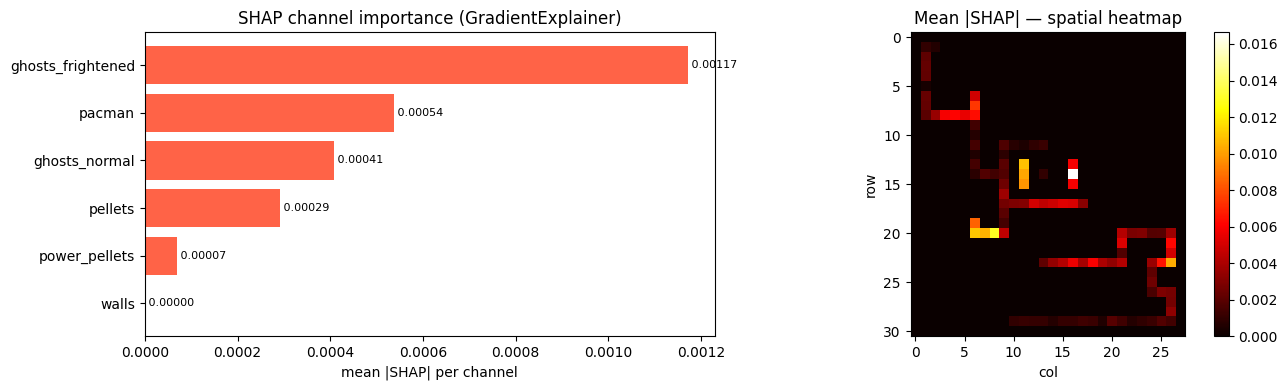

In [29]:
CHANNEL_NAMES = ['walls', 'pellets', 'power_pellets', 'pacman', 'ghosts_normal', 'ghosts_frightened']
channel_shap_1d = np.array(channel_shap).flatten()[:len(CHANNEL_NAMES)]
order = np.argsort(channel_shap_1d)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: SHAP channel importances
axes[0].barh([CHANNEL_NAMES[i] for i in order],
             [channel_shap_1d[i] for i in order],
             color='tomato')
axes[0].set_xlabel('mean |SHAP| per channel')
axes[0].set_title('SHAP channel importance (GradientExplainer)')
for i, v in enumerate([channel_shap_1d[j] for j in order]):
    axes[0].text(v, i, f' {v:.5f}', va='center', fontsize=8)

# Right: spatial SHAP heatmap averaged over samples and channels
spatial_mean = shap_arr.mean(axis=(0, 1))               # (31, 28)
im = axes[1].imshow(spatial_mean, cmap='hot', interpolation='nearest')
axes[1].set_title('Mean |SHAP| — spatial heatmap')
axes[1].set_xlabel('col'); axes[1].set_ylabel('row')
plt.colorbar(im, ax=axes[1], fraction=0.03)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'interpretability_shap.png', dpi=150)

plt.show()

## Discussion

- **Permutation importance** measures how much the PPO critic's V(s) drops when a given input channel is replaced with random data from other states. A large drop → that channel is crucial for the value estimate.
- **SHAP GradientExplainer** gives gradient-based attributions that tell us *which pixels and channels* most influence V(s). The spatial heatmap shows which regions of the maze the network focuses on.
- We expect `pacman` and `ghosts_normal` to dominate — the agent must track its position relative to the nearest ghost and pellet. `pellets` should also be important as the primary reward source. `walls` should score low since they are static.
- Both figures are saved to [`reports/`](../reports/).


## 3. Training progress — learning curves from MLflow

Ładujemy metryki ze wszystkich rund eksperymentu `rl_training` i rysujemy:
- **mean reward (last 50 ep)** vs liczba kroków  
- **mean episode length (last 50 ep)** vs liczba kroków  

Dzięki temu widać różnicę między starym DQN (brak postępu) a nowym MaskablePPO+CNN.

In [26]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# MLflowLogger writes to mlruns/mlflow.db (SQLite backend)
MLFLOW_DB = (Path('..') / 'mlruns' / 'mlflow.db').resolve()
print(f"MLflow DB: {MLFLOW_DB}  (exists={MLFLOW_DB.exists()})")

tracking_uri = f"sqlite:///{MLFLOW_DB}"
mlflow.set_tracking_uri(tracking_uri)
client = mlflow.tracking.MlflowClient(tracking_uri=tracking_uri)

# Collect all runs from the 'rl_training' experiment
experiment = client.get_experiment_by_name('rl_training')
if experiment is None:
    exps = client.search_experiments()
    print("Available experiments:", [(e.experiment_id, e.name) for e in exps])
else:
    runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        order_by=["attributes.start_time ASC"],
    )
    print(f"Found {len(runs)} run(s) in 'rl_training':")
    for r in runs:
        name   = r.data.tags.get('mlflow.runName', r.info.run_id[:8])
        algo   = r.data.params.get('algorithm', '?')
        steps  = r.data.metrics.get('total_timesteps', '?')
        last_r = r.data.metrics.get('mean_reward_50ep', '?')
        print(f"  {name:25s}  algo={algo:15s}  total_steps={steps}  last_mean_r={last_r}")


MLflow DB: /home/mwrona/PAC-MAN-AI/mlruns/mlflow.db  (exists=True)
Found 2 run(s) in 'rl_training':
  dqn_indefinite             algo=DQN              total_steps=2115277.0  last_mean_r=-1295.6
  ppo_cnn_masked             algo=MaskablePPO      total_steps=5001216.0  last_mean_r=3.8564300537109375


Computing random agent baseline (100 episodes)...
Random agent mean reward: -14.700


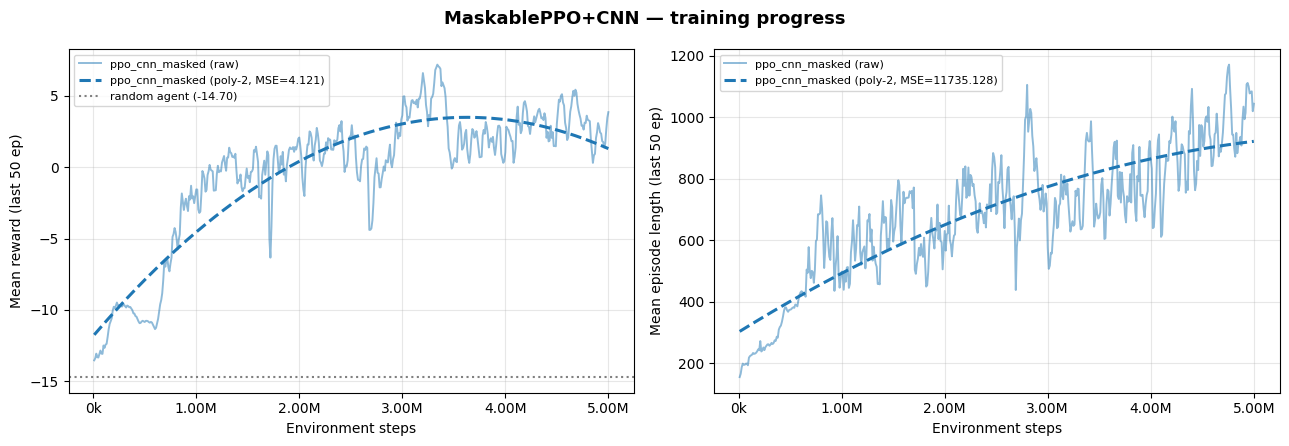

Saved → ../reports/training_curves_ppo.png


In [27]:
import numpy as np
from src.environment.pacman_env import PacmanGridEnv


def load_metric(run, metric_name):
    """Return (steps, values) arrays for a given metric in a run."""
    history = client.get_metric_history(run.info.run_id, metric_name)
    if not history:
        return None, None
    history.sort(key=lambda m: m.step)
    return np.array([m.step for m in history]), np.array([m.value for m in history])


def random_agent_mean_reward(n_episodes=100, seed=0):
    """Run a random agent and return mean episode reward."""
    env_r = PacmanGridEnv()
    ep_rewards = []
    for ep in range(n_episodes):
        obs, _ = env_r.reset(seed=seed + ep)
        total = 0.0
        done = False
        while not done:
            action = env_r.action_space.sample()
            obs, r, terminated, truncated, _ = env_r.step(action)
            total += r
            done = terminated or truncated
        ep_rewards.append(total)
    env_r.close()
    return float(np.mean(ep_rewards))


if experiment is None:
    print("Brak eksperymentu 'rl_training' — najpierw uruchom komórkę powyżej.")
else:
    # Filter to PPO run only
    ppo_runs = [r for r in runs
                if 'ppo' in r.data.tags.get('mlflow.runName', '').lower()]
    if not ppo_runs:
        print("Brak runu PPO w eksperymencie 'rl_training'.")
    else:
        print("Computing random agent baseline (100 episodes)...")
        random_baseline = random_agent_mean_reward(n_episodes=100, seed=0)
        print(f"Random agent mean reward: {random_baseline:.3f}")

        METRICS = [
            ('mean_reward_50ep',  'Mean reward (last 50 ep)'),
            ('mean_ep_length_50', 'Mean episode length (last 50 ep)'),
        ]

        POLY_DEG = 2
        fig, axes = plt.subplots(1, len(METRICS), figsize=(13, 4.5))
        fig.suptitle('MaskablePPO+CNN — training progress', fontsize=13, fontweight='bold')
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

        for ax, (metric, ylabel) in zip(axes, METRICS):
            ax.set_xlabel('Environment steps')
            ax.set_ylabel(ylabel)
            ax.grid(True, alpha=0.3)
            ax.xaxis.set_major_formatter(
                mticker.FuncFormatter(
                    lambda x, _: f'{x/1e6:.2f}M' if x >= 1e6 else f'{x/1e3:.0f}k'
                )
            )

            for i, run in enumerate(ppo_runs):
                run_name = run.data.tags.get('mlflow.runName', run.info.run_id[:8])
                color = colors[i % len(colors)]
                steps, values = load_metric(run, metric)
                if steps is None:
                    continue

                # Raw curve
                ax.plot(steps, values, color=color, linewidth=1.4,
                        alpha=0.5, label=f'{run_name} (raw)')

                # Polynomial trend line (degree 2)
                if len(steps) >= POLY_DEG + 1:
                    coeffs = np.polyfit(steps, values, POLY_DEG)
                    trend  = np.polyval(coeffs, steps)
                    mse    = float(np.mean((values - trend) ** 2))
                    ax.plot(steps, trend, color=color, linewidth=2.2,
                            linestyle='--',
                            label=f'{run_name} (poly-{POLY_DEG}, MSE={mse:.3f})')

            # Random baseline — only meaningful for reward subplot
            if metric == 'mean_reward_50ep':
                ax.axhline(random_baseline, color='gray', linewidth=1.5,
                           linestyle=':', label=f'random agent ({random_baseline:.2f})')

            ax.legend(fontsize=8)

        plt.tight_layout()
        fig.savefig(REPORTS_DIR / 'training_curves_ppo.png', dpi=150)
        plt.show()
        print(f"Saved → {REPORTS_DIR / 'training_curves_ppo.png'}")
